# Прогнозирование перепада давления при стенозе с использованием машинного обучения на основе геометрических и гемодинамических параметров

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score
)

## 1. Подготовка данных для обучения моделей

In [27]:
df = pd.read_csv('../data/data4_2.csv',sep=',')
eps = 1e-6
Ds = df["Degree of stenosis"]
Re = df["Re"]
Lr = df["Stenosis length/Radius"]
asym = df["Asymmetry"]

df["As"] = 1 - (1 - Ds)**2
df["area_ratio"] = 1 / ((1 - Ds)**2 + eps)

df["Ds2"] = Ds**2
df["Ds3"] = Ds**3

df["log_Re"] = np.log(Re + eps)

df["Lr_Ds"] = Lr * Ds
df["Lr_area_ratio"] = Lr * df["area_ratio"]

df["logRe_Ds"] = df["log_Re"] * Ds
df["logRe_area_ratio"] = df["log_Re"] * df["area_ratio"]

df["asym_Ds"] = asym * Ds
df["asym_area_ratio"] = asym * df["area_ratio"]
X = df.drop(['Pressure difference'], axis=1)
y = df['Pressure difference']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Расширение признакового пространства

К исходным признакам `Re`, `Stenosis length/Radius`, `Degree of stenosis` и `Asymmetry` добавляются производные признаки, учитывающие нелинейность зависимости перепада давления от степени стеноза и взаимодействия между параметрами.

Обозначения:

- $S$ — степень стеноза (`Degree of stenosis`);
- $Re$ — число Рейнольдса;
- $L_r$ — относительная длина стеноза (`Stenosis length/Radius`);
- $\alpha$ — параметр асимметрии;
- $\varepsilon = 10^{-6}$ — малое число для предотвращения деления на ноль и вычисления логарифма от нуля.

| Признак в данных | Формула | Что учитывает |
|---|---|---|
| `As` | $1-(1-S)^2$ | Относительное уменьшение площади просвета |
| `area_ratio` | $\dfrac{1}{(1-S)^2+\varepsilon}$ | Величину, обратную относительной площади просвета |
| `Ds2` | $S^2$ | Квадратичную нелинейность степени стеноза |
| `Ds3` | $S^3$ | Кубическую нелинейность степени стеноза |
| `log_Re` | $\ln(Re+\varepsilon)$ | Логарифмическое представление режима течения |
| `Lr_Ds` | $L_r \cdot S$ | Совместное влияние длины и степени стеноза |
| `Lr_area_ratio` | $L_r \cdot \dfrac{1}{(1-S)^2+\varepsilon}$ | Совместное влияние длины стеноза и площади просвета |
| `logRe_Ds` | $\ln(Re+\varepsilon)\cdot S$ | Взаимодействие режима течения и степени стеноза |
| `logRe_area_ratio` | $\ln(Re+\varepsilon)\cdot \dfrac{1}{(1-S)^2+\varepsilon}$ | Взаимодействие режима течения и площади просвета |
| `asym_Ds` | $\alpha \cdot S$ | Совместное влияние асимметрии и степени стеноза |
| `asym_area_ratio` | $\alpha \cdot \dfrac{1}{(1-S)^2+\varepsilon}$ | Совместное влияние асимметрии и площади просвета |

После добавления признаков столбец `Pressure difference` используется как целевая переменная, а остальные столбцы формируют матрицу признаков. Данные разделяются на обучающую и тестовую выборки в отношении 80/20 с `random_state=42`.

In [28]:
X.head()

,Re,Stenosis length/Radius,Degree of stenosis,Asymmetry,As,area_ratio,Ds2,Ds3,log_Re,Lr_Ds,Lr_area_ratio,logRe_Ds,logRe_area_ratio,asym_Ds,asym_area_ratio
0,30,5.0,0.0,1.0,0.0,0.999999,0.0,0.0,3.401197,0.0,4.999995,0.0,3.401194,0.0,0.999999
1,50,5.0,0.0,1.0,0.0,0.999999,0.0,0.0,3.912023,0.0,4.999995,0.0,3.912019,0.0,0.999999
2,100,5.0,0.0,1.0,0.0,0.999999,0.0,0.0,4.605170,0.0,4.999995,0.0,4.605166,0.0,0.999999
3,200,5.0,0.0,1.0,0.0,0.999999,0.0,0.0,5.298317,0.0,4.999995,0.0,5.298312,0.0,0.999999
4,300,5.0,0.0,1.0,0.0,0.999999,0.0,0.0,5.703782,0.0,4.999995,0.0,5.703777,0.0,0.999999


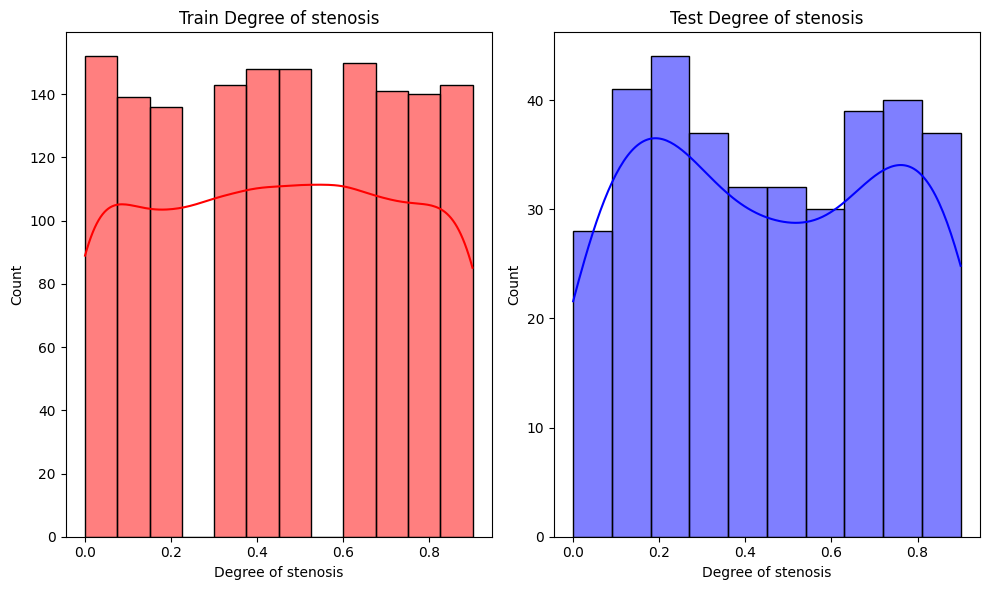

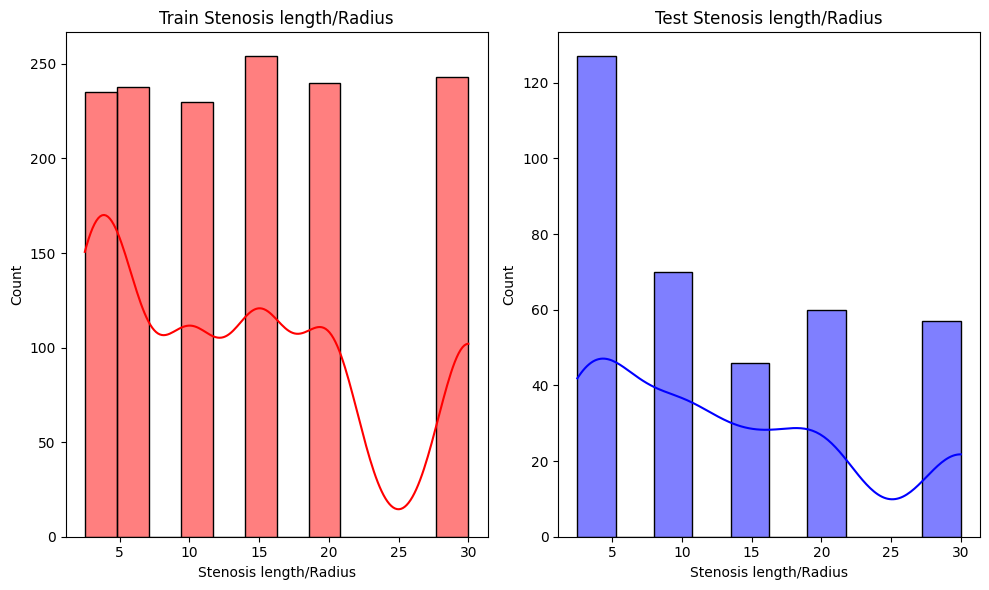

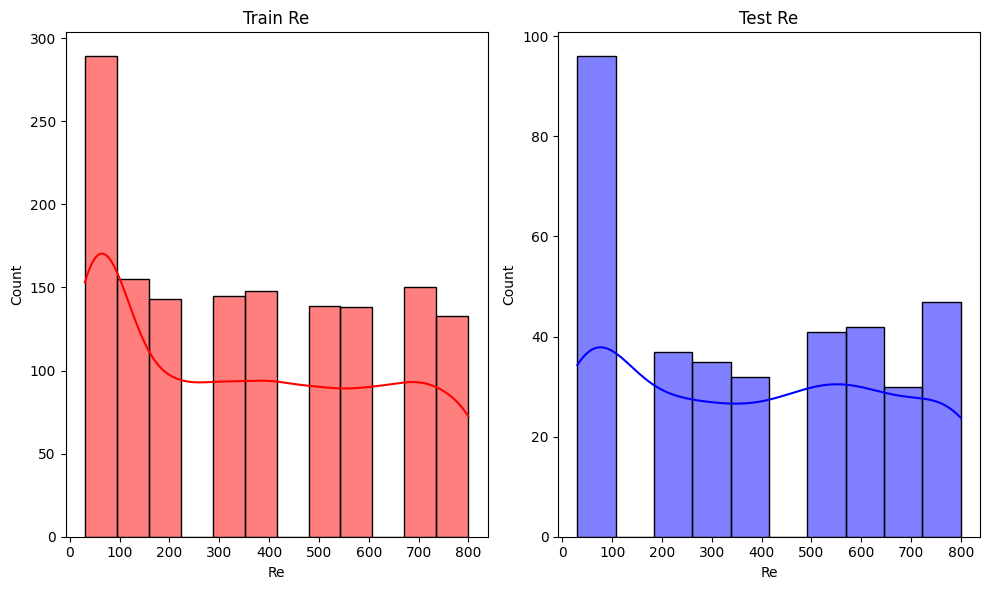

In [29]:
def train_test_plot(train, test, X):
    plt.figure(figsize=(10,6))

    plt.subplot(1,2,1)
    sns.histplot(train[X], kde=True, color ='red')
    plt.title(f'Train {X}')

    plt.subplot(1,2,2)
    sns.histplot(test[X], kde=True, color='blue')
    plt.title(f'Test {X}')

    plt.tight_layout()
    plt.show()

train_test_plot(X_train, X_test, 'Degree of stenosis')
train_test_plot(X_train, X_test, 'Stenosis length/Radius') 
train_test_plot(X_train, X_test, 'Re')


## 2. Построение моделей

In [30]:
groups_train = (
    X_train['Degree of stenosis'].round(6).astype(str) + '_' +
    X_train['Stenosis length/Radius'].round(6).astype(str)
)
gkf = GroupKFold(n_splits=5)

In [31]:
def preprocessor(model, scale_X=False):
    log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True)

    numeric = [
    'Re',
    'Stenosis length/Radius',
    'Degree of stenosis',
    'Asymmetry',
    'As',
    'area_ratio',
    'Ds2',
    'Ds3',
    'log_Re',
    'Lr_Ds',
    'Lr_area_ratio',
    'logRe_Ds',
    'logRe_area_ratio',
    'asym_Ds',
    'asym_area_ratio',
]

    num_transformer = StandardScaler() if scale_X else 'passthrough'

    preprocessor = ColumnTransformer([
        ('num', num_transformer, numeric),
    ])

    regressor = TransformedTargetRegressor(
        regressor=model,
        transformer=log_transformer
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])
    return pipeline

In [32]:
def report_and_plots(y_train, train_pred, y_test, y_pred):
    # Метрики
    mae_train = mean_absolute_error(y_train, train_pred)
    mae_test  = mean_absolute_error(y_test,  y_pred)

    medae_train = median_absolute_error(y_train, train_pred)
    medae_test  = median_absolute_error(y_test,  y_pred)

    mse_train = mean_squared_error(y_train, train_pred)
    mse_test  = mean_squared_error(y_test,  y_pred)

    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)

    mean_abs_test = np.mean(np.abs(y_test))
    nmae_test = 100 * mae_test / mean_abs_test

    r2 = r2_score(y_test, y_pred)

    print(f"MAE (обучение) = {mae_train:,.0f}")
    print(f"MAE (тест)     = {mae_test:,.0f}")
    print(f"MedianAE (обучение)= {medae_train:,.0f}")
    print(f"MedianAE (тест)= {medae_test:,.0f}")
    print(f"MSE (обучение) = {mse_train:,.0f}")
    print(f"MSE (тест)     = {mse_test:,.0f}")
    print(f"RMSE (обучение)= {rmse_train:,.0f}")
    print(f"RMSE (тест)    = {rmse_test:,.0f}")
    print(f"Отн. ошибка (MAE/mean|y|) на тесте = {nmae_test:.2f}%")
    print(f"R² (тест) = {r2:.4f}")

   
    plt.figure()
    plt.bar(["Обучение", "Тест"], [mae_train, mae_test])
    plt.ylabel("MAE (абс. ошибка)")
    plt.title("Ошибка на обучении и тесте")
    plt.show()


    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.6)
    mn = min(np.min(y_test), np.min(y_pred))
    mx = max(np.max(y_test), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Истинное значение")
    plt.ylabel("Предсказание")
    plt.title("Истинное vs предсказанное (тест)")
    plt.show()


    abs_err = np.abs(y_test - y_pred)
    plt.figure()
    plt.hist(abs_err, bins=30)
    plt.xlabel("|Ошибка|")
    plt.ylabel("Количество примеров")
    plt.title("Распределение абсолютной ошибки (тест)")
    plt.show()

In [33]:
def run_model(model, scale_X=False):
    pipeline = preprocessor(model, scale_X=scale_X)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    train_pred = pipeline.predict(X_train)

    report_and_plots(y_train, train_pred, y_test, y_pred)

    regressor_step = pipeline.named_steps['regressor']
    regressor_fitted = getattr(regressor_step, 'regressor_', regressor_step)

    names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    names = pd.Series(names).str.replace('num__', '', regex=False)

    # Для деревьев / леса / XGBoost
    if hasattr(regressor_fitted, 'feature_importances_'):
        importance = pd.DataFrame({
            'feature': names,
            'importance': regressor_fitted.feature_importances_
        }).sort_values(by='importance', ascending=False)

        print("\nВажность признаков:")
        print(importance)

    # Для линейной регрессии
    elif hasattr(regressor_fitted, 'coef_'):
        coef_df = pd.DataFrame({
            'feature': names,
            'coefficient': regressor_fitted.coef_
        }).sort_values(by='coefficient', key=lambda s: s.abs(), ascending=False)

        print("\nКоэффициенты признаков:")
        print(coef_df)
        print(f"\nIntercept: {regressor_fitted.intercept_}")

    else:
        print("\nУ этой модели нет feature_importances_ или coef_")

    return pipeline

### 2.1. Линейная регрессия

In [34]:
from sklearn.linear_model import Ridge

def linear_model(alpha=1.0):
    model_lr = Ridge(alpha=alpha)
    model_lr_pip = run_model(model_lr, scale_X=True)
    return model_lr_pip

### 2.2. Метод ближайших соседей (knn)

In [35]:
def knn_model(n_neighbors=5, weights='distance', p=1):
    model_knn = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p
    )

    model_knn_pip = run_model(model_knn, scale_X=True)
    return model_knn_pip

## 3. Обучение и оценка качества

MAE (обучение) = 124
MAE (тест)     = 139
MedianAE (обучение)= 2
MedianAE (тест)= 1
MSE (обучение) = 456,625
MSE (тест)     = 589,245
RMSE (обучение)= 676
RMSE (тест)    = 768
Отн. ошибка (MAE/mean|y|) на тесте = 15.92%
R² (тест) = 0.9163


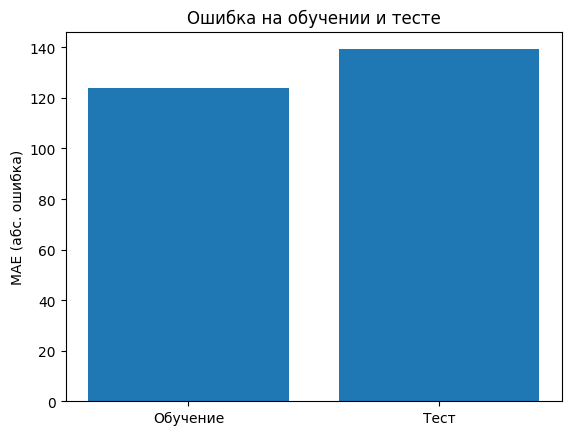

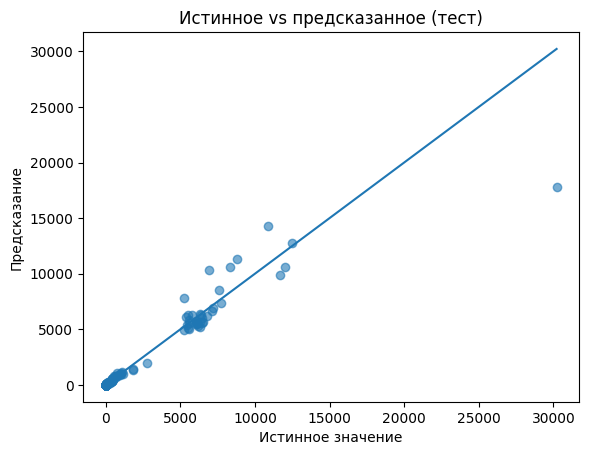

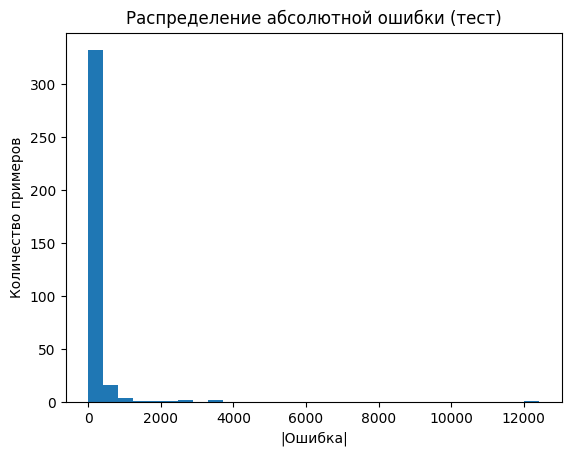


Коэффициенты признаков:
                   feature  coefficient
7                      Ds3     1.066943
8                   log_Re    -1.001078
11                logRe_Ds     0.690814
6                      Ds2     0.554318
5               area_ratio     0.404809
4                       As    -0.309932
1   Stenosis length/Radius     0.295615
0                       Re     0.239064
12        logRe_area_ratio     0.101986
10           Lr_area_ratio    -0.094220
2       Degree of stenosis     0.082335
13                 asym_Ds     0.053228
9                    Lr_Ds    -0.014325
14         asym_area_ratio    -0.008790
3                Asymmetry    -0.003549

Intercept: 3.384611775520248


In [36]:
lr_model = linear_model()

In [37]:
def knn_model(
    n_neighbors=7,
    weights='distance',
    p=3,
    algorithm='auto',
    leaf_size=100,
    metric='minkowski'
):
    model_knn = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        algorithm=algorithm,
        leaf_size=leaf_size,
        metric=metric
    )

    model_knn_pip = run_model(model_knn, scale_X=True)
    return model_knn_pip

MAE (обучение) = 0
MAE (тест)     = 111
MedianAE (обучение)= 0
MedianAE (тест)= 2
MSE (обучение) = 0
MSE (тест)     = 841,585
RMSE (обучение)= 0
RMSE (тест)    = 917
Отн. ошибка (MAE/mean|y|) на тесте = 12.66%
R² (тест) = 0.8804


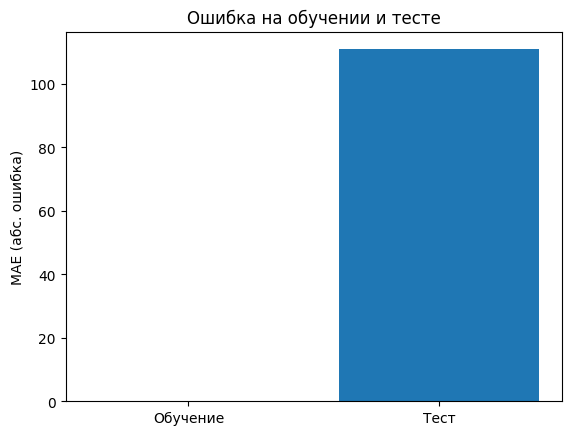

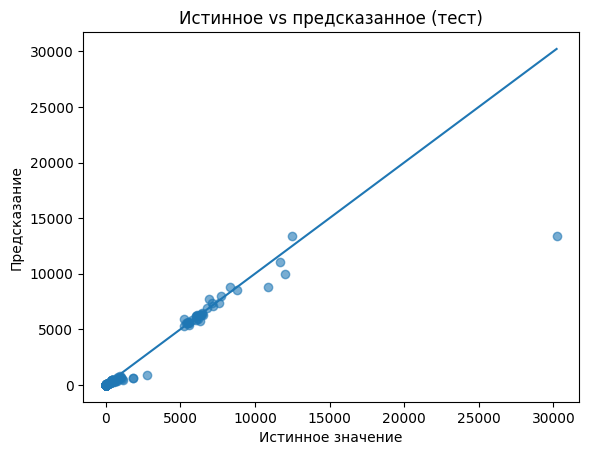

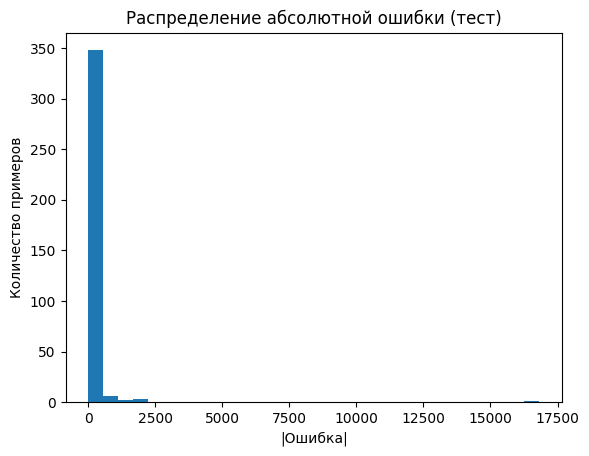


У этой модели нет feature_importances_ или coef_


In [38]:
model_knn_pip = knn_model() 

In [39]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

all_models = {
    "lr": lr_model,
    "knn": model_knn_pip,
}

joblib.dump(all_models, "../models/all_models1.joblib")
print("Модели сохранены в ../models/all_models1.joblib")

Модели сохранены в ../models/all_models1.joblib
